In [1]:
%pip install -q librosa pandas numpy matplotlib soundfile
%pip install -q pathlib
%pip install -q torchaudio


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import numpy as np
import librosa
import glob
from pathlib import Path

In [3]:
# 1. Configuration & Paths
BASE_DIR = Path('/Users/ganapathychidambaram/Desktop/birds/birdclef-2026')
TRAIN_AUDIO_DIR = BASE_DIR / 'train_audio'
TRAIN_SOUNDSCAPES_DIR = BASE_DIR / 'train_soundscapes'

In [4]:
# 2. Load Core Metadata
# Essential for mapping audio files to species labels [cite: 9, 21]
train_df = pd.read_csv(BASE_DIR / 'train.csv') 
# Provides common names and higher-level classification (e.g., Insecta) [cite: 15, 21]
taxonomy_df = pd.read_csv(BASE_DIR / 'taxonomy.csv') 
# Template for the required final output format [cite: 32, 29]
sample_sub = pd.read_csv(BASE_DIR / 'sample_submission.csv')

In [5]:
# 3. Global Constants
# Standardized sampling rate mentioned in the dataset description 
SR = 32000 
# Every audio recording in the test set is split into 5-second windows [cite: 28, 34]
WINDOW_SIZE = 5

In [6]:
print(f"Loaded {len(train_df)} training records across {train_df['primary_label'].nunique()} species.")

Loaded 35549 training records across 206 species.


In [7]:
column_to_check = 'label_idx'

if column_to_check in train_df.columns:
    print(f"✅ '{column_to_check}' is present in the DataFrame.")
else:
    print(f"❌ '{column_to_check}' is MISSING.")

❌ 'label_idx' is MISSING.


In [8]:
import librosa.display
import matplotlib.pyplot as plt

In [9]:
# 1. Select a sample file from the training metadata
sample_row = train_df.iloc[0]
sample_path = TRAIN_AUDIO_DIR/sample_row['filename']

# 2. Load the file using our standardized sampling rate
# We load just 5 seconds to match the test window size
y, sr = librosa.load(sample_path, sr=SR, duration=WINDOW_SIZE)

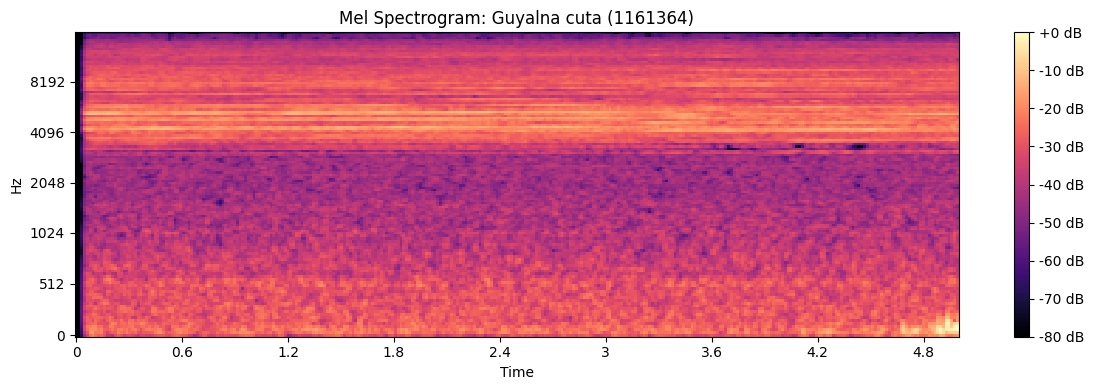

In [10]:
# 3. Create the Mel Spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=16000)
S_dB = librosa.power_to_db(S, ref=np.max)

# 4. Plotting
plt.figure(figsize=(12, 4))
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', fmax=16000)
plt.colorbar(format='%+2.0f dB')
plt.title(f"Mel Spectrogram: {sample_row['common_name']} ({sample_row['primary_label']})")
plt.tight_layout()
plt.show()

### Saves a sound file as a numpy vector file in a directory of your choice

More precisely, saves a 2D NumPy representation of the processed audio (mel spectrogram)

In [11]:
import numpy as np
import librosa
from pathlib import Path

# 1. Create a directory for the processed features
PROCESSED_DIR = Path('processed_features_apr_25_2')
PROCESSED_DIR.mkdir(exist_ok=True)
"""
    Min-Max scales a dB spectrogram to the 0.0 - 1.0 range.
    Separated to ensure identical logic between training and inference.
def normalize_spectrogram(S_dB):

    spec_min = S_dB.min()
    spec_max = S_dB.max()
    
    if spec_max - spec_min > 0:
        return (S_dB - spec_min) / (spec_max - spec_min)
    else:
        return np.zeros_like(S_dB)
"""
def encode_audio_to_spectrogram(row, save_dir):
    """Loads audio, converts to Mel Spectrogram, and invokes normalization."""
    try:
        # Load exactly 5 seconds to match WINDOW_SIZE
        file_path = TRAIN_AUDIO_DIR / row['filename']
        y, _ = librosa.load(file_path, sr=SR, duration=WINDOW_SIZE)
        
        # Pad with zeros if the audio is shorter than 5 seconds
        if len(y) < SR * WINDOW_SIZE:
            y = np.pad(y, (0, SR * WINDOW_SIZE - len(y)))

        # Generate Mel Spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=128, fmax=16000)
        S_dB = librosa.power_to_db(S, ref=np.max)

        # Invoke the separate normalization method
        # S_normalized = normalize_spectrogram(S_dB)

        # Save as a compact .npy file
        save_name = Path(row['filename']).stem + '.npy'
        np.save(save_dir / save_name, S_dB)
        return True
    except Exception as e:
        print(f"Error processing {row['filename']}: {e}")
        return False


### Process a small batch (e.g., the first 50 files) using the above method

In [12]:

test_batch = train_df.head(50)
print(f"Starting batch processing for {len(test_batch)} files...")

success_count = 0
for _, row in test_batch.iterrows():
    if encode_audio_to_spectrogram(row, PROCESSED_DIR):
        success_count += 1

print(f"Finished! Successfully encoded {success_count} files into {PROCESSED_DIR}/")

Starting batch processing for 50 files...
Finished! Successfully encoded 50 files into processed_features_apr_25_2/


### Runs spectrogram conversion pipeline over the full dataset and saves one .npy feature file per audio clip.

In [13]:
from tqdm.auto import tqdm
import time

# 1. Clear out previous test run if desired, or skip existing files
def process_full_dataset(df, save_dir):
    success_count = 0
    # tqdm creates a functional progress bar in your notebook
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Encoding Audio"):
        save_name = Path(row['filename']).stem + '.npy'
        save_path = save_dir / save_name
        
        # Skip if already processed (resumable)
        if save_path.exists():
            success_count += 1
            continue
            
        if encode_audio_to_spectrogram(row, save_dir):
            success_count += 1
            
    return success_count

# 2. Run for the entire train_df
# Note: Ensure you have ~15-20GB of free space for the .npy files
total_encoded = process_full_dataset(train_df, PROCESSED_DIR)
print(f"Final Count: {total_encoded} spectrograms ready in {PROCESSED_DIR}")

Encoding Audio:   0%|          | 0/35549 [00:00<?, ?it/s]

Final Count: 35549 spectrograms ready in processed_features_apr_25_2


### Encoding: convert the bird species labels (strings) into integer IDs that the model can use.

In [14]:
from sklearn.preprocessing import LabelEncoder

# 1. Initialize the encoder
encoder = LabelEncoder()

# 2. Fit on the primary labels from your metadata
# This creates a consistent mapping from species ID to a number
train_df['label_id'] = encoder.fit_transform(train_df['primary_label'])

# 3. Save the mapping for later (important for the final submission!)
species_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

print(f"Mapped {len(species_mapping)} species to integer labels.")
print(f"Example: {train_df.iloc[0]['primary_label']} is now label {train_df.iloc[0]['label_id']}")


Mapped 206 species to integer labels.
Example: 1161364 is now label 0


### Species Distribution Analysis
how frequent is each species?

In [15]:
%pip install -q seaborn

Note: you may need to restart the kernel to use updated packages.


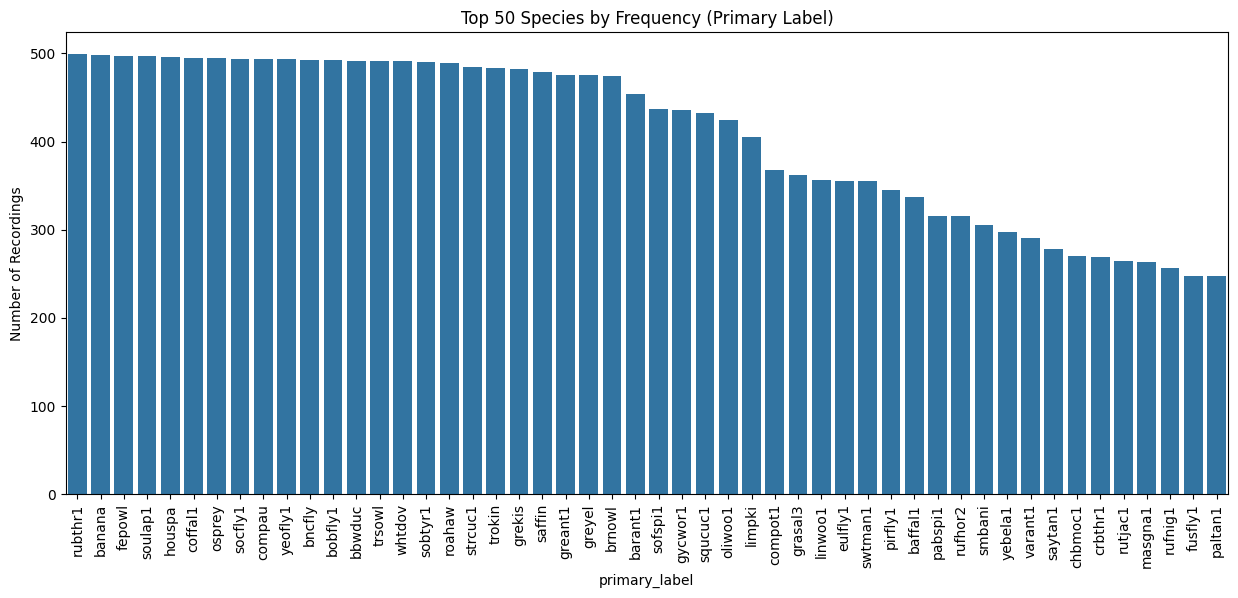

Most frequent species: rubthr1 (499 files)
Least frequent species: 516975 (1 files)


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Count occurrences per species
species_counts = train_df['primary_label'].value_counts()

# 2. Plot the distribution
plt.figure(figsize=(15, 6))
sns.barplot(x=species_counts.index[:50], y=species_counts.values[:50])
plt.xticks(rotation=90)
plt.title("Top 50 Species by Frequency (Primary Label)")
plt.ylabel("Number of Recordings")
plt.show()

print(f"Most frequent species: {species_counts.index[0]} ({species_counts.max()} files)")
print(f"Least frequent species: {species_counts.index[-1]} ({species_counts.min()} files)")

## Stratified Sampling

Correct the underrepresented species: "If a species has fewer than 50 samples, repeat its records until it reaches 50."

In [17]:
# 1. Define a target minimum number of samples per species
TARGET_MIN = 50

# 2. Create a balanced dataframe
balanced_list = []
for label in train_df['primary_label'].unique():
    species_group = train_df[train_df['primary_label'] == label]
    
    if len(species_group) < TARGET_MIN:
        # 'Oversample' by repeating the rare species records
        oversampled_group = species_group.sample(TARGET_MIN, replace=True, random_state=42)
        balanced_list.append(oversampled_group)
    else:
        # Keep the original data for common species
        balanced_list.append(species_group)

balanced_df = pd.concat(balanced_list).reset_index(drop=True)

print(f"Original Dataset: {len(train_df)} records")
print(f"Balanced Dataset: {len(balanced_df)} records")
print(f"Minimum samples per species now: {balanced_df['primary_label'].value_counts().min()}")

Original Dataset: 35549 records
Balanced Dataset: 37376 records
Minimum samples per species now: 50


In [18]:
from sklearn.model_selection import train_test_split

train_df_split, val_df = train_test_split(
    balanced_df,
    test_size=0.2,
    stratify=balanced_df['primary_label'],  # important for class balance
    random_state=42
)

### Load the saved spectrograms, converts them into tensors, and batches them so that the model can train efficiently.

In [19]:
import random
import torch
from torch.utils.data import Dataset, DataLoader

class BirdDataset(Dataset):
    def __init__(self, df, processed_dir, num_classes=206, mixup_count=5000, transform=None):
            self.df = df
            self.processed_dir = processed_dir
            self.num_classes = num_classes
            self.transform = transform
            
            # FIX: Ensure this is defined here!
            self.base_len = len(df) 
            self.mixup_count = mixup_count

    def __len__(self):
        # This will now work because self.base_len exists
        return self.base_len + self.mixup_count

    def get_label(self, row):
            """Helper to convert primary_label to a one-hot vector."""
            # print("debug 4.1 ") 
            label_vec = np.zeros(self.num_classes, dtype=np.float32)
            # print("debug 4.2 ") 
            # Ensure 'label_id' was created during your train_df preprocessing
            #row['label_idx']
            # print("debug 4.3") 
            label_vec[row['label_id']] = 1.0
            return label_vec        

    def __getitem__(self, idx):
            # CASE 1: Normal Index (The original clean samples)
            # print("debug 1")
            if idx < self.base_len:
                # print("debug 2")
                row = self.df.iloc[idx]
                # print("debug 3")
                image = np.load(self.processed_dir / f"{Path(row['filename']).stem}.npy")
                # print("debug 4")
                label = self.get_label(row)
                # print("debug 5")
                
            # CASE 2: Mixture Index (The extra 5000 samples)
            else:
                # Pick two random samples from the base 80%
                # print("debug 2 - random sample route")
                idx1 = random.randint(0, self.base_len - 1)
                idx2 = random.randint(0, self.base_len - 1)
                
                row1 = self.df.iloc[idx1]
                row2 = self.df.iloc[idx2]
                
                img1 = np.load(self.processed_dir / f"{Path(row1['filename']).stem}.npy")
                img2 = np.load(self.processed_dir / f"{Path(row2['filename']).stem}.npy")
                
                lbl1 = self.get_label(row1)
                lbl2 = self.get_label(row2)
                
                # Blend weight (Lambda) from Beta distribution
                # Beta(1,1) is a uniform distribution (0 to 1)
                lam = np.random.beta(1.0, 1.0)
                
                image = (lam * img1) + ((1 - lam) * img2)
                label = (lam * lbl1) + ((1 - lam) * lbl2)
    
    
            # Convert to tensor (EfficientNet-B0 expects [Channel, H, W])
            # Unnormalized dB values are usually single channel
            image_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
            label_tensor = torch.tensor(label, dtype=torch.float32)

            # Apply spectral augmentations AFTER conversion (image_tensor is now a proper tensor)
            if self.transform:
                image_tensor = self.transform(image_tensor)
    
            return image_tensor, label_tensor



In [20]:
from torchaudio.transforms import FrequencyMasking, TimeMasking
import torch.nn as nn

spec_aug = nn.Sequential(
    FrequencyMasking(freq_mask_param=24),
    TimeMasking(time_mask_param=64),
)


train_dataset = BirdDataset(
    train_df_split,
    PROCESSED_DIR,
    mixup_count=5000,
    transform=spec_aug # keep mixup here
)

val_dataset = BirdDataset(
    val_df,
    PROCESSED_DIR,
    mixup_count=0      # ❗ disable mixup
)

In [21]:


# Initialize the DataLoader
# batch_size=32 is a safe starting point for MacBook Air memory
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Test one batch
features, labels = next(iter(train_loader))
print(f"Batch Shape: {features.shape}") # Expect [32, 1, 128, 313]
print(f"Labels Shape: {labels.shape}")     # Expect [32]

Batch Shape: torch.Size([32, 1, 128, 313])
Labels Shape: torch.Size([32, 206])


### Construct the Neural Net Architecture

In [22]:
%pip install -q timm

import timm
import torch.nn as nn

Note: you may need to restart the kernel to use updated packages.


In [23]:
class BirdModel(nn.Module):
    def __init__(self, num_classes):
        super(BirdModel, self).__init__()
        # 1. Load a pre-trained EfficientNet-B0
        # in_chans=1 because our spectrograms are grayscale (1 channel)
        self.backbone = timm.create_model('efficientnet_b0', 
                                          pretrained=True, 
                                          num_classes=0, 
                                          in_chans=1)
        
        # 2. Get the number of features from the backbone output
        num_features = self.backbone.num_features
        
        # 3. Define the final classification head
        self.fc = nn.Linear(num_features, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.fc(x)
        return x

# Initialize the model
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = BirdModel(num_classes=206).to(device)

print(f"Model initialized on: {device}")

Model initialized on: mps


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import os

# =========================
# 1. Hyperparameters
# =========================
EPOCHS = 20
# Max training limit — early stopping will likely trigger before this

EARLY_STOPPING_PATIENCE = 6
# Increased from 5 → gives the model more room to improve before stopping
# Important because LR is still high in early epochs, so temporary plateaus are expected

EARLY_STOPPING_MIN_DELTA = 1e-4
# Minimum improvement to reset patience counter
# Filters out noise — tiny fluctuations don't count as real improvement

# =========================
# 2. Loss and Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
# Correct loss for multi-label classification + mixup
# Expects raw logits (not sigmoid-ed outputs)

optimizer = optim.Adam([
    {"params": model.backbone.parameters(), "lr": 3e-5},
    # Small LR for pretrained backbone — preserves learned ImageNet features
    # Slightly increased from 1e-5 to allow faster adaptation to bird spectrograms

    {"params": model.fc.parameters(), "lr": 3e-4},
    # Larger LR for classifier head — trained from scratch so can afford bigger steps
    # Maintains 10x ratio over backbone LR (standard best practice)
])

# =========================
# 3. Scheduler
# =========================
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,
    # First cosine cycle runs for 10 epochs — LR decays from max → eta_min
    # Aligns with expected early stopping window (~6-10 epochs)

    T_mult=1,
    # Each restart uses the same cycle length (10 epochs)
    # If training continues past epoch 10, the LR resets and decays again
    # Prevents the flat eta_min problem of plain CosineAnnealingLR

    eta_min=1e-6
    # Floor LR — allows fine-grained weight updates at end of each cycle
)

# =========================
# 3. Training Loop
# =========================
print(f"Starting training for {EPOCHS} epochs...")
best_val_loss = float('inf')
save_dir = "mixup_v2_may_2"
os.makedirs(save_dir, exist_ok=True)

# Early stopping state
epochs_no_improve = 0
early_stopped = False

for epoch in range(EPOCHS):
    # -------------------------
    # TRAINING PHASE
    # -------------------------
    model.train()
    running_loss = 0.0
    current_lr = scheduler.get_last_lr()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train] LR={current_lr}")

    for i, (inputs, labels) in enumerate(pbar):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix(loss=running_loss / (i + 1))

    avg_train_loss = running_loss / len(train_loader)
    scheduler.step()

    # -------------------------
    # VALIDATION PHASE
    # -------------------------
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs = val_inputs.to(device)
            val_labels = val_labels.to(device)
            val_outputs = model(val_inputs)
            v_loss = criterion(val_outputs, val_labels)
            val_loss += v_loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # -------------------------
    # EARLY STOPPING CHECK
    # -------------------------
    if avg_val_loss < best_val_loss - EARLY_STOPPING_MIN_DELTA:
        # Genuine improvement — reset patience counter
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        best_save_path = os.path.join(save_dir, "bird_model_best.pth")
        torch.save(model.state_dict(), best_save_path)
        print(f"  ✅ Val loss improved → {best_val_loss:.4f} | Saved Best Model")
    else:
        # No improvement
        epochs_no_improve += 1
        print(f"  ⚠️ No improvement for {epochs_no_improve}/{EARLY_STOPPING_PATIENCE} epochs")
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\n🛑 Early stopping triggered at epoch {epoch+1}!")
            early_stopped = True

    # -------------------------
    # EPOCH SUMMARY
    # -------------------------
    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f} | Val Loss = {avg_val_loss:.4f} | LR = {scheduler.get_last_lr()}")

    if early_stopped:
        break

# =========================
# 4. Save Final Model
# =========================
save_path = os.path.join(save_dir, "bird_model_final.pth")
torch.save(model.state_dict(), save_path)
print(f"\nFinal model saved at: {save_path}")

if early_stopped:
    print(f"Training stopped early at epoch {epoch+1}/{EPOCHS}")
    print(f"Best model (val loss: {best_val_loss:.4f}) saved at: {best_save_path}")
else:
    print(f"Training completed all {EPOCHS} epochs")
    print(f"Best val loss: {best_val_loss:.4f} | Best model saved at: {best_save_path}")

Starting training for 20 epochs...


Epoch 1/20 [Train] LR=[3e-05, 0.0003]:   0%|          | 0/1091 [00:00<?, ?it/s]

  ✅ Val loss improved → 0.0285 | Saved Best Model
Epoch 1: Train Loss = 0.0418 | Val Loss = 0.0285 | LR = [2.929031948627973e-05, 0.0002926829491861254]


Epoch 2/20 [Train] LR=[2.929031948627973e-05, 0.0002926829491861254]:   0%|          | 0/1091 [00:00<?, ?it/s]

  ✅ Val loss improved → 0.0248 | Saved Best Model
Epoch 2: Train Loss = 0.0274 | Val Loss = 0.0248 | LR = [2.7230746418436738e-05, 0.0002714480406590546]


...

  ✅ Val loss improved → 0.0092 | Saved Best Model
Epoch 18: Train Loss = 0.0090 | Val Loss = 0.0092 | LR = [3.769253581563264e-06, 2.955195934094537e-05]


Epoch 19/20 [Train] LR=[3.769253581563264e-06, 2.955195934094537e-05]:   0%|          | 0/1091 [00:00<?, ?it/s…

  ⚠️ No improvement for 1/6 epochs
Epoch 19: Train Loss = 0.0087 | Val Loss = 0.0093 | LR = [1.7096805137202739e-06, 8.317050813874547e-06]


Epoch 20/20 [Train] LR=[1.7096805137202739e-06, 8.317050813874547e-06]:   0%|          | 0/1091 [00:00<?, ?it/…

  ⚠️ No improvement for 2/6 epochs
Epoch 20: Train Loss = 0.0086 | Val Loss = 0.0092 | LR = [3e-05, 0.0003]

Final model saved at: mixup_v2_may_2/bird_model_final.pth
Training completed all 20 epochs
Best val loss: 0.0092 | Best model saved at: mixup_v2_may_2/bird_model_best.pth


### Inference Script

In [25]:
import torch
import librosa
import numpy as np

# 1. Setup metadata for decoding
# This ensures we convert the model's '0, 1, 2' back to 'species_name'
id_to_species = {v: k for k, v in species_mapping.items()}

def predict_audio(file_path, model, device, threshold=0.05):
    model.eval()
    # Load audio (32kHz)
    y, _ = librosa.load(file_path, sr=32000)
    
    # Calculate number of 5-second segments
    segment_len = 32000 * 5
    predictions = []

    with torch.no_grad():
        for i in range(0, len(y), segment_len):
            chunk = y[i:i + segment_len]
            
            # Pad if the last chunk is shorter than 5 seconds
            if len(chunk) < segment_len:
                chunk = np.pad(chunk, (0, segment_len - len(chunk)))
            
            # Convert to Mel Spectrogram
            S = librosa.feature.melspectrogram(y=chunk, sr=32000, n_mels=128, fmax=16000)
            S_dB = librosa.power_to_db(S, ref=np.max)
            
            # Prepare tensor [Batch, Channel, Height, Width]
            input_tensor = torch.from_numpy(S_dB)[None, None, ...].float().to(device)
            
            # Get model output and apply Sigmoid/Softmax
            output = model(input_tensor)
            probs = torch.softmax(output, dim=1).cpu().numpy()[0]
            
            # Get species that pass the confidence threshold
            top_indices = np.where(probs > threshold)[0]
            found_species = [id_to_species[idx] for idx in top_indices]
            
            # If no species passes threshold, label as 'nocall'
            predictions.append(found_species if found_species else ['nocall'])
            
    return predictions

# Test it on a file from your training set to see if it works!
test_file = TRAIN_AUDIO_DIR / train_df.iloc[0]['filename']
results = predict_audio(test_file, model, device)
print(f"Predictions for {test_file.name}: {results[:5]}")

Predictions for iNat1216197.ogg: [['1161364'], ['1161364'], ['1161364', 'brnowl', 'compot1'], ['greyel', 'limpki']]


In [26]:
# Try running the inference again with a higher threshold
results_clean = predict_audio(test_file, model, device, threshold=0.30)
print(f"Refined Predictions: {results_clean[:5]}")

Refined Predictions: [['1161364'], ['1161364'], ['1161364'], ['limpki']]


### Optimization - Doesn't work

In [27]:
"""
import numpy as np
from sklearn.metrics import average_precision_score
 Finds the threshold that maximizes the Mean Average Precision (mAP).

def optimize_threshold(target_labels, predicted_probs):
    thresholds = np.arange(0.0, 0.51, 0.01) # Testing 0.0 to 0.50
    best_threshold = 0.0
    best_score = 0.0
    
    print("Searching for optimal threshold...")
    
    for t in thresholds:
        # Apply threshold: 1 if prob > t, else 0
        current_preds = (predicted_probs > t).astype(int)
        
        # Calculate score (using macro average for mAP)
        # Note: BirdCLEF uses a specialized CMAP, but AP is a strong local proxy
        score = average_precision_score(target_labels, current_preds, average='macro')
        
        if score > best_score:
            best_score = score
            best_threshold = t
            
    print(f"--- Search Complete ---")
    print(f"Best Local Threshold: {best_threshold:.2f}")
    print(f"Best Local mAP: {best_score:.4f}")
    
    return best_threshold

# --- HOW TO USE THIS ---
# 1. Ensure you have 'oof_labels' (true labels from your validation set)
# 2. Ensure you have 'oof_probs' (the raw sigmoid/softmax outputs from your model)
# 3. Uncomment and run the line below:
# opt_t = optimize_threshold(oof_labels, oof_probs)
"""

'\nimport numpy as np\nfrom sklearn.metrics import average_precision_score\n Finds the threshold that maximizes the Mean Average Precision (mAP).\n\ndef optimize_threshold(target_labels, predicted_probs):\n    thresholds = np.arange(0.0, 0.51, 0.01) # Testing 0.0 to 0.50\n    best_threshold = 0.0\n    best_score = 0.0\n\n    print("Searching for optimal threshold...")\n\n    for t in thresholds:\n        # Apply threshold: 1 if prob > t, else 0\n        current_preds = (predicted_probs > t).astype(int)\n\n        # Calculate score (using macro average for mAP)\n        # Note: BirdCLEF uses a specialized CMAP, but AP is a strong local proxy\n        score = average_precision_score(target_labels, current_preds, average=\'macro\')\n\n        if score > best_score:\n            best_score = score\n            best_threshold = t\n\n    print(f"--- Search Complete ---")\n    print(f"Best Local Threshold: {best_threshold:.2f}")\n    print(f"Best Local mAP: {best_score:.4f}")\n\n    return be